all time in minutes
H3 is the area division and metric

decided not to used vehicles dataset cause it didnt have enough info and the age of the vehicle my guess is it doesnt affect the iddle

In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import numpy as np
import matplotlib.pyplot as plt
import h3


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.cluster import DBSCAN


In [2]:
DATA_PATH = "/Users/zuzakutowska/Desktop//voi_data/"

In [3]:
RELOCATION_THRESHOLD = 480

In [4]:

df_idling = pd.read_parquet(DATA_PATH + "idling_voi.parquet")
df_area = pd.read_parquet(DATA_PATH + "service_area_voi.parquet")
df_trips = pd.read_parquet(DATA_PATH + "trips_voi.parquet")

df_weather = pd.read_csv(DATA_PATH + "voi_weather.csv", skiprows=2)



## Train/Test split

Will be done with respect to time.
We want to prevent future events based on the past, so later in the app the later period fo time will be the one we didi th eprediction on.
The split will be done: 1.5 years for train and 0.5 years for test.

The datasets that will be split are only df_trips and df_idling, the rest is static.

In [5]:
print(df_idling["starttime"].min())
print(df_idling["starttime"].max())

print(df_trips["starttime"].min())
print(df_trips["starttime"].max())

1685570410
1748728689
1685570410
1748728687


In [6]:
cutoff = 1735689600
threshold_seconds = RELOCATION_THRESHOLD * 60

train_idling = df_idling[
    df_idling["starttime"] < (cutoff - threshold_seconds)
].copy()

test_idling = df_idling[
    df_idling["starttime"] >= cutoff
].copy()

train_trips = df_trips[
    df_trips["starttime"] < cutoff
].copy()

test_trips = df_trips[
    df_trips["starttime"] >= cutoff
].copy()

In [7]:
print(train_idling["starttime"].min(), train_idling["starttime"].max())
print(test_idling["starttime"].min(), test_idling["starttime"].max())

print(train_trips["starttime"].min(), train_trips["starttime"].max())
print(test_trips["starttime"].min(), test_trips["starttime"].max())

1685570410 1735599484
1735939621 1748728689
1685570410 1735599253
1735939628 1748728687


## EDA + cleaning

all transformation and cleaning will be done based on decision. made looking only at train set and then blindly applied to test.

1) Idling dataset

In [8]:
train_idling.head()

,id,lat,lon,starttime,endtime
0,voiescooter2ptm,48.128991,11.703202,1685570410,1685615953
1,voiescooterm9se,48.150385,11.465454,1685570425,1685570964
2,voiescooternedt,48.121186,11.497221,1685570429,1685590410
3,voiescootergqqg,48.134003,11.497714,1685570429,1685696259
4,voiescooter8qu7,48.090939,11.521176,1685570434,1685617063


In [9]:
train_idling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4129437 entries, 0 to 4129436
Data columns (total 5 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         object 
 1   lat        float64
 2   lon        float64
 3   starttime  int64  
 4   endtime    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 189.0+ MB


In [10]:
# check for missing values
train_idling.isna().sum()

id           0
lat          0
lon          0
starttime    0
endtime      0
dtype: int64

In [11]:
# check for duplicates
train_idling.duplicated().sum()

np.int64(0)

In [12]:
# change time format
train_idling["starttime"] = pd.to_datetime(train_idling["starttime"], unit="s")
train_idling["endtime"] = pd.to_datetime(train_idling["endtime"], unit="s")

test_idling["starttime"] = pd.to_datetime(test_idling["starttime"], unit="s")
test_idling["endtime"] = pd.to_datetime(test_idling["endtime"], unit="s")

2) Area dataset

In [13]:
df_area.head()

,provider,geom_service_area
0,voi,"MULTIPOLYGON(((11.685091 48.137744,11.687027 4..."


In [14]:
# creating a geodataframe from the service area dataframe
df_area["geometry"] = df_area["geom_service_area"].apply(wkt.loads)
gdf_area = gpd.GeoDataFrame(df_area, geometry="geometry", crs="EPSG:4326")


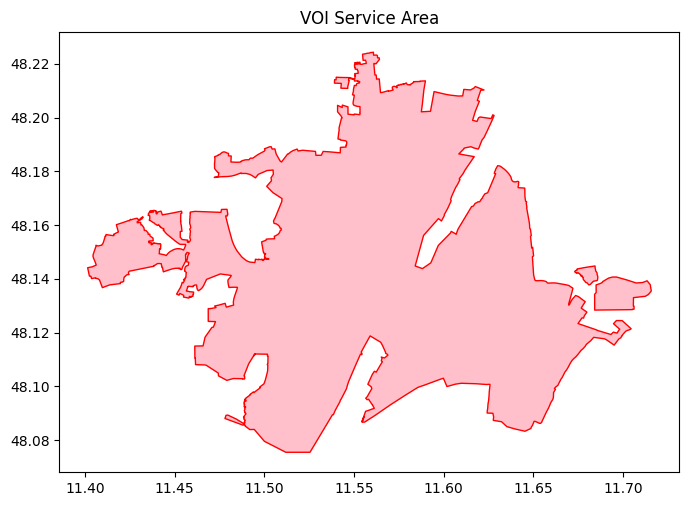

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
gdf_area.plot(ax=ax, facecolor="pink", edgecolor="red")
plt.title("VOI Service Area")
plt.show()

3) Trips dataset

In [16]:
train_trips.head()

,id,startlat,startlon,starttime,endlat,endlon,endtime
780,voiescooter22kg,48.112692,11.536804,1685614367,48.107439,11.539265,1685614725
781,voiescooter22kg,48.107439,11.539265,1685616534,48.103970,11.531430,1685633815
782,voiescooter22kg,48.103970,11.531430,1685912447,48.104310,11.535567,1685913525
783,voiescooter22kg,48.104310,11.535567,1685915330,48.112454,11.537146,1685916227
784,voiescooter22kg,48.112454,11.537146,1685943042,48.112089,11.549275,1685943585


In [17]:
# checking for null values
train_trips.isnull().sum()

id           0
startlat     0
startlon     0
starttime    0
endlat       0
endlon       0
endtime      0
dtype: int64

In [18]:
# checking for duplicates
train_trips.duplicated().sum()

np.int64(0)

In [19]:
# change time format 
train_trips["starttime"] = pd.to_datetime(train_trips["starttime"], unit="s")
train_trips["endtime"] = pd.to_datetime(train_trips["endtime"], unit="s")

test_trips["starttime"] = pd.to_datetime(test_trips["starttime"], unit="s")
test_trips["endtime"] = pd.to_datetime(test_trips["endtime"], unit="s")

In [20]:
trip_starts_by_hour = (
    train_trips
    .assign(hour=train_trips["starttime"].dt.hour)
    .groupby("hour")
    .size()
)

print(trip_starts_by_hour)

hour
0      58044
1      43893
2      34535
3      45274
4      69145
5     126449
6     167737
7     162318
8     141091
9     150801
10    179848
11    208383
12    223092
13    241277
14    267835
15    292104
16    300162
17    281841
18    232896
19    188088
20    162894
21    147526
22    109560
23     78290
dtype: int64


4. Weather data

In [21]:
df_weather.head()

,time,temperature_2m (°C),precipitation (mm),weather_code (wmo code),wind_speed_10m (km/h)
0,2023-05-31T00:00,13.0,0.0,0,12.4
1,2023-05-31T01:00,12.0,0.0,0,10.6
2,2023-05-31T02:00,11.0,0.0,0,9.3
3,2023-05-31T03:00,10.5,0.0,0,10.0
4,2023-05-31T04:00,10.5,0.0,0,10.6


In [22]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time                     17568 non-null  object 
 1   temperature_2m (°C)      17568 non-null  float64
 2   precipitation (mm)       17568 non-null  float64
 3   weather_code (wmo code)  17568 non-null  int64  
 4   wind_speed_10m (km/h)    17568 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 686.4+ KB


In [23]:
df_weather.isnull().sum()

time                       0
temperature_2m (°C)        0
precipitation (mm)         0
weather_code (wmo code)    0
wind_speed_10m (km/h)      0
dtype: int64

## Feature engineering

1) Idling dataset

- add the target value, imouted from the starttine and endtime
- create and area variable using H3
- add a list of neighbouring H3 cells (will use it later to calculate demand in locations close to the H3)
- add time features: hour, weekday, is_weekend, month, time_of_day
- calculate average iddle time per H3 and number of iddle scooters per H3

after running the model and getting bead results i decided to also add these new features:
- number of idle scooters in the H3 and neighbour H3s at the moment of an idle event
- Distance from the nearest scooter (not yet adding it)

In [24]:
def engineer_idling_features(df):
    df = df.copy()

    # target
    df["idle_duration_min"] = (
        df["endtime"] - df["starttime"]
    ).dt.total_seconds() / 60
    
    df["needs_relocation"] = (
        df["idle_duration_min"] >= RELOCATION_THRESHOLD 
    ).astype(int)

    # spatial features
    df["h3_cell"] = df.apply(
        lambda row: h3.latlng_to_cell(row["lat"], row["lon"], 9),
        axis=1
    )

    df["neighbor_h3"] = df["h3_cell"].apply(
        lambda cell: list(h3.grid_ring(cell, 1))
    )

    # temporal features
    df["hour"] = df["starttime"].dt.hour
    df["weekday"] = df["starttime"].dt.dayofweek
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)
    df["month"] = df["starttime"].dt.month

    def get_time_of_day(hour):
        if 5 <= hour < 12:
            return "morning"
        elif 12 <= hour < 17:
            return "afternoon"
        elif 17 <= hour < 22:
            return "evening"
        else:
            return "night"

    df["time_of_day"] = df["hour"].apply(get_time_of_day)

    return df


train_idling = engineer_idling_features(train_idling)
test_idling = engineer_idling_features(test_idling)


In [25]:
print(train_idling["needs_relocation"].value_counts())
print(train_idling["needs_relocation"].value_counts(normalize=True))

needs_relocation
0    2752790
1    1376647
Name: count, dtype: int64
needs_relocation
0    0.666626
1    0.333374
Name: proportion, dtype: float64


In [26]:
# historical H3 features
# only completed idle events can be used as historical information

def add_historical_idle_features(idling_df, history_df):
    df = idling_df.copy()

    # build historical table from completed idle events
    history = history_df[
        ["h3_cell", "endtime", "idle_duration_min"]
    ].copy()

    history = history.sort_values(["h3_cell", "endtime"])

    # cumulative historical statistics
    history["historical_idle_count_h3"] = (
        history.groupby("h3_cell").cumcount() + 1
    )

    history["historical_avg_idle_h3"] = (
        history.groupby("h3_cell")["idle_duration_min"]
        .expanding()
        .mean()
        .reset_index(level=0, drop=True)
    )

    # keep only the information needed for the join
    history = history[
        [
            "h3_cell",
            "endtime",
            "historical_idle_count_h3",
            "historical_avg_idle_h3"
        ]
    ]

    # merge_asof needs time ordering
    df = df.sort_values("starttime")
    history = history.sort_values("endtime")

    df = pd.merge_asof(
        df,
        history,
        left_on="starttime",
        right_on="endtime",
        by="h3_cell",
        direction="backward",
        allow_exact_matches=False,
        suffixes=("", "_history")
    )

    # remove the historical endtime created by the merge
    df = df.drop(columns=["endtime_history"])

    return df


train_idling = add_historical_idle_features(
    train_idling,
    train_idling
)

idle_history = pd.concat(
    [train_idling, test_idling],
    ignore_index=True
)

test_idling = add_historical_idle_features(
    test_idling,
    idle_history
)

In [27]:
# suppply features

# =====================================================
# 3. Scooter Supply Features
# =====================================================

# Build the complete historical fleet-state table.
# We use both train and test here ONLY to reconstruct which scooters were
# physically idle at each timestamp. Future-starting scooters are never counted.

all_idling_state = pd.concat(
    [
        train_idling[["id", "h3_cell", "starttime", "endtime"]],
        test_idling[["id", "h3_cell", "starttime", "endtime"]]
    ],
    ignore_index=True
)


# -----------------------------------------------------
# Prepare lookup tables
# -----------------------------------------------------

# For every H3, store all idle start and end times in chronological order.
# This allows us to count active scooters very quickly using searchsorted.

starts_by_h3 = {
    cell: group["starttime"]
        .sort_values()
        .to_numpy(dtype="datetime64[ns]")
    for cell, group in all_idling_state.groupby("h3_cell")
}

ends_by_h3 = {
    cell: group["endtime"]
        .sort_values()
        .to_numpy(dtype="datetime64[ns]")
    for cell, group in all_idling_state.groupby("h3_cell")
}


EMPTY_TIMES = np.array([], dtype="datetime64[ns]")


# -----------------------------------------------------
# Calculate supply at each idle-event timestamp
# -----------------------------------------------------

def add_supply_features(df):
    df = df.copy()

    same_h3 = pd.Series(0, index=df.index, dtype=np.int64)
    neighbor_h3 = pd.Series(0, index=df.index, dtype=np.int64)

    # Loop over H3 cells, NOT individual rows.
    # This is much faster for millions of observations.
    for cell, group in df.groupby("h3_cell"):

        times = group["starttime"].to_numpy(
            dtype="datetime64[ns]"
        )

        # -----------------------------
        # Scooters in current H3
        # -----------------------------

        starts = starts_by_h3.get(cell, EMPTY_TIMES)
        ends = ends_by_h3.get(cell, EMPTY_TIMES)

        active_same = (
            np.searchsorted(starts, times, side="right")
            -
            np.searchsorted(ends, times, side="right")
        )

        same_h3.loc[group.index] = active_same


        # -----------------------------
        # Scooters in neighbouring H3s
        # -----------------------------

        active_neighbors = np.zeros(
            len(group),
            dtype=np.int32
        )

        for neighbor in h3.grid_ring(cell, 1):

            neighbor_starts = starts_by_h3.get(
                neighbor,
                EMPTY_TIMES
            )

            neighbor_ends = ends_by_h3.get(
                neighbor,
                EMPTY_TIMES
            )

            active_neighbors += (
                np.searchsorted(
                    neighbor_starts,
                    times,
                    side="right"
                )
                -
                np.searchsorted(
                    neighbor_ends,
                    times,
                    side="right"
                )
            )

        neighbor_h3.loc[group.index] = active_neighbors


    # Add features
    df["idle_scooters_same_h3"] = same_h3
    df["idle_scooters_neighbor_h3"] = neighbor_h3

    df["idle_scooters_local_total"] = (
        df["idle_scooters_same_h3"]
        + df["idle_scooters_neighbor_h3"]
    )

    return df


train_idling = add_supply_features(train_idling)
test_idling = add_supply_features(test_idling)

historical_idle_count_h3 counts how many idle events have already happened in that H3 before the current observation.
historical_avg_idle_h3 calculates the average idle duration of only the previous events in that H3. The current row is shifted out before the average is calculated, which prevents target leakage.

In [28]:
train_idling.head()

,id,lat,lon,starttime,endtime,idle_duration_min,needs_relocation,h3_cell,neighbor_h3,hour,weekday,is_weekend,month,time_of_day,historical_idle_count_h3,historical_avg_idle_h3,idle_scooters_same_h3,idle_scooters_neighbor_h3,idle_scooters_local_total
0,voiescooter2ptm,48.128991,11.703202,2023-05-31 22:00:10,2023-06-01 10:39:13,759.050000,1,891f8d7adb3ffff,"[891f8d71e4bffff, 891f8d7ad87ffff, 891f8d7adbb...",22,2,0,5,night,NaN,NaN,1,0,1
1,voiescooterm9se,48.150385,11.465454,2023-05-31 22:00:25,2023-05-31 22:09:24,8.983333,0,891f8d45197ffff,"[891f8d4552fffff, 891f8d45193ffff, 891f8d45183...",22,2,0,5,night,NaN,NaN,1,0,1
2,voiescooternedt,48.121186,11.497221,2023-05-31 22:00:29,2023-06-01 03:33:30,333.016667,0,891f8d45e23ffff,"[891f8d45e33ffff, 891f8d45e3bffff, 891f8d45e2b...",22,2,0,5,night,NaN,NaN,1,0,1
3,voiescootergqqg,48.134003,11.497714,2023-05-31 22:00:29,2023-06-02 08:57:39,2097.166667,1,891f8d45c7bffff,"[891f8d45c47ffff, 891f8d45c4fffff, 891f8d45eb7...",22,2,0,5,night,NaN,NaN,1,0,1
4,voiescooter8qu7,48.090939,11.521176,2023-05-31 22:00:34,2023-06-01 10:57:43,777.150000,1,891f8d7b417ffff,"[891f8d7b48fffff, 891f8d7b413ffff, 891f8d7b403...",22,2,0,5,night,NaN,NaN,1,0,1


2) Area dataset all done

3) Trips dataste

- trip duration (check for lentghs of the trips )
- calculate historical demand per H3
- find no of trips in the last 24h per H3 and in the last week per H3

After runnign the model and the performance was bad i decided to add the following features:
- Relative demand: number of trips from the H3 by number of idle scooters
- Use the demand of neighbour H3s
- Time since last rental in the H3

In [29]:
# =====================================================
# 1. Basic Trip Features
# =====================================================

def engineer_trip_features(df):
    df = df.copy()

    # trip duration - mainly for EDA
    df["trip_duration_min"] = (
        df["endtime"] - df["starttime"]
    ).dt.total_seconds() / 60

    # trip pickup location = demand location
    df["h3_cell"] = df.apply(
        lambda row: h3.latlng_to_cell(
            row["startlat"],
            row["startlon"],
            9
        ),
        axis=1
    )

    df = df.sort_values("starttime").copy()

    return df


train_trips = engineer_trip_features(train_trips)
test_trips = engineer_trip_features(test_trips)

In [30]:
# =====================================================
# 2. Recent Demand Features
# =====================================================

def create_trip_demand_features(df):
    df = df.copy()
    df = df.sort_values(["h3_cell", "starttime"])

    # number of trips in the H3 during previous 24 hours
    df["trips_last_24h_h3"] = (
        df
        .set_index("starttime")
        .groupby("h3_cell")["id"]
        .rolling("24h")
        .count()
        .reset_index(level=0, drop=True)
        .to_numpy()
    )

    # number of trips in the H3 during previous 7 days
    df["trips_last_7d_h3"] = (
        df
        .set_index("starttime")
        .groupby("h3_cell")["id"]
        .rolling("7d")
        .count()
        .reset_index(level=0, drop=True)
        .to_numpy()
    )

    # time since previous trip in the H3
    df["time_since_last_trip_h3_min"] = (
        df.groupby("h3_cell")["starttime"]
        .diff()
        .dt.total_seconds() / 60
    )
    
    return df



train_trips_demand = create_trip_demand_features(
    train_trips
)

all_trips = pd.concat(
    [train_trips, test_trips],
    ignore_index=True
)

all_trips_demand = create_trip_demand_features(
    all_trips
)

In [31]:
# =====================================================
# 3. Attach Demand Features to Idle Events
# =====================================================

def attach_demand_features(idling_df, trips_demand_df):
    idle = idling_df.copy()

    demand = trips_demand_df[
        [
            "h3_cell",
            "starttime",
            "trips_last_24h_h3",
            "trips_last_7d_h3"
        ]
    ].copy()

    # rename trip timestamp so we retain it after the merge
    demand = demand.rename(
        columns={"starttime": "last_trip_time"}
    )

    idle = idle.sort_values("starttime")
    demand = demand.sort_values("last_trip_time")

    result = pd.merge_asof(
        idle,
        demand,
        left_on="starttime",
        right_on="last_trip_time",
        by="h3_cell",
        direction="backward",
        allow_exact_matches=False
    )

    # how recently a rental occurred in this H3
    result["time_since_last_trip_h3_min"] = (
        result["starttime"]
        - result["last_trip_time"]
    ).dt.total_seconds() / 60

    return result


train_idling = attach_demand_features(
    train_idling,
    train_trips_demand
)

test_idling = attach_demand_features(
    test_idling,
    all_trips_demand
)

In [32]:
# =====================================================
# 4. Neighbour Demand Features
# =====================================================

EMPTY_TIMES = np.array([], dtype="datetime64[ns]")


def build_trip_lookup(trips_df):
    return {
        cell: group["starttime"]
        .sort_values()
        .to_numpy(dtype="datetime64[ns]")
        for cell, group in trips_df.groupby("h3_cell")
    }


train_trip_lookup = build_trip_lookup(train_trips)
test_trip_lookup = build_trip_lookup(all_trips)

In [33]:
print(train_idling.columns.tolist())

['id', 'lat', 'lon', 'starttime', 'endtime', 'idle_duration_min', 'needs_relocation', 'h3_cell', 'neighbor_h3', 'hour', 'weekday', 'is_weekend', 'month', 'time_of_day', 'historical_idle_count_h3', 'historical_avg_idle_h3', 'idle_scooters_same_h3', 'idle_scooters_neighbor_h3', 'idle_scooters_local_total', 'last_trip_time', 'trips_last_24h_h3', 'trips_last_7d_h3', 'time_since_last_trip_h3_min']


In [34]:
print(train_trips_demand.columns.tolist())

['id', 'startlat', 'startlon', 'starttime', 'endlat', 'endlon', 'endtime', 'trip_duration_min', 'h3_cell', 'trips_last_24h_h3', 'trips_last_7d_h3', 'time_since_last_trip_h3_min']


In [35]:
def add_neighbor_demand(df, trip_lookup):
    df = df.copy()

    neighbor_24h = pd.Series(
        0, index=df.index, dtype="int32"
    )

    neighbor_7d = pd.Series(
        0, index=df.index, dtype="int32"
    )

    for cell, group in df.groupby("h3_cell"):

        times = group["starttime"].to_numpy(
            dtype="datetime64[ns]"
        )

        start_24h = times - np.timedelta64(24, "h")
        start_7d = times - np.timedelta64(7, "D")

        count_24h = np.zeros(len(group), dtype=np.int32)
        count_7d = np.zeros(len(group), dtype=np.int32)

        for neighbor in h3.grid_ring(cell, 1):

            trip_times = trip_lookup.get(
                neighbor,
                EMPTY_TIMES
            )

            if len(trip_times) == 0:
                continue

            end_pos = np.searchsorted(
                trip_times,
                times,
                side="left"
            )

            count_24h += (
                end_pos
                - np.searchsorted(
                    trip_times,
                    start_24h,
                    side="left"
                )
            )

            count_7d += (
                end_pos
                - np.searchsorted(
                    trip_times,
                    start_7d,
                    side="left"
                )
            )

        neighbor_24h.loc[group.index] = count_24h
        neighbor_7d.loc[group.index] = count_7d

    df["trips_last_24h_neighbor_h3"] = neighbor_24h
    df["trips_last_7d_neighbor_h3"] = neighbor_7d

    return df


train_idling = add_neighbor_demand(
    train_idling,
    train_trip_lookup
)

test_idling = add_neighbor_demand(
    test_idling,
    test_trip_lookup
)

In [36]:
# =====================================================
# 5. Relative Demand Features
# =====================================================

for df in [train_idling, test_idling]:

    df["relative_demand_24h_h3"] = np.divide(
        df["trips_last_24h_h3"],
        df["idle_scooters_same_h3"],
        out=np.zeros(len(df), dtype=float),
        where=df["idle_scooters_same_h3"] > 0
    )

    df["local_trips_24h"] = (
        df["trips_last_24h_h3"]
        + df["trips_last_24h_neighbor_h3"]
    )

    df["relative_demand_24h_local"] = np.divide(
        df["local_trips_24h"],
        df["idle_scooters_local_total"],
        out=np.zeros(len(df), dtype=float),
        where=df["idle_scooters_local_total"] > 0
    )

## Testing how the join looks

In [37]:
train_idling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4129437 entries, 0 to 4129436
Data columns (total 28 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   id                           object        
 1   lat                          float64       
 2   lon                          float64       
 3   starttime                    datetime64[ns]
 4   endtime                      datetime64[ns]
 5   idle_duration_min            float64       
 6   needs_relocation             int64         
 7   h3_cell                      object        
 8   neighbor_h3                  object        
 9   hour                         int32         
 10  weekday                      int32         
 11  is_weekend                   int64         
 12  month                        int32         
 13  time_of_day                  object        
 14  historical_idle_count_h3     float64       
 15  historical_avg_idle_h3       float64       
 16  

4. Weather feature egineeirng, and join witht the data

In [38]:
# =====================================================
# 6. Weather Features
# =====================================================

# -----------------------------------------------------
# Clean Open-Meteo dataframe
# -----------------------------------------------------

# Your current df_weather has metadata in the first rows.
# Row 1 contains the real column names, so rebuild from there.

weather = df_weather.iloc[1:].copy()

weather.columns = [
    "time",
    "temperature_2m",
    "precipitation",
    "weather_code",
    "wind_speed_10m"
]


# remove the row that contains column labels
weather = weather.iloc[1:].copy()

# convert time
weather["time"] = pd.to_datetime(
    weather["time"]
)

# convert weather variables to numeric
weather_cols = [
    "temperature_2m",
    "precipitation",
    "weather_code",
    "wind_speed_10m"
]

weather[weather_cols] = weather[weather_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# -----------------------------------------------------
# Additional simple weather features
# -----------------------------------------------------

weather["is_raining"] = (
    weather["precipitation"] > 0
).astype(int)

weather["is_bad_weather"] = (
    (weather["precipitation"] > 0)
    | (weather["wind_speed_10m"] > 25)
).astype(int)


# -----------------------------------------------------
# Match scooter observations to hourly weather
# -----------------------------------------------------

# Weather is hourly, so map each idle event to its hour
train_idling["weather_hour"] = (
    train_idling["starttime"].dt.floor("h")
)

test_idling["weather_hour"] = (
    test_idling["starttime"].dt.floor("h")
)


# Merge hourly Munich weather onto each idle event
train_idling = train_idling.merge(
    weather,
    left_on="weather_hour",
    right_on="time",
    how="left"
)

test_idling = test_idling.merge(
    weather,
    left_on="weather_hour",
    right_on="time",
    how="left"
)


# -----------------------------------------------------
# Remove helper columns
# -----------------------------------------------------

train_idling.drop(
    columns=["weather_hour", "time"],
    inplace=True
)

test_idling.drop(
    columns=["weather_hour", "time"],
    inplace=True
)

In [39]:
train_idling.head(25)

,id,lat,lon,starttime,endtime,idle_duration_min,needs_relocation,h3_cell,neighbor_h3,hour,...,trips_last_7d_neighbor_h3,relative_demand_24h_h3,local_trips_24h,relative_demand_24h_local,temperature_2m,precipitation,weather_code,wind_speed_10m,is_raining,is_bad_weather
0,voiescooter2ptm,48.128991,11.703202,2023-05-31 22:00:10,2023-06-01 10:39:13,759.050000,1,891f8d7adb3ffff,"[891f8d71e4bffff, 891f8d7ad87ffff, 891f8d7adbb...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
1,voiescooterm9se,48.150385,11.465454,2023-05-31 22:00:25,2023-05-31 22:09:24,8.983333,0,891f8d45197ffff,"[891f8d4552fffff, 891f8d45193ffff, 891f8d45183...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
2,voiescooternedt,48.121186,11.497221,2023-05-31 22:00:29,2023-06-01 03:33:30,333.016667,0,891f8d45e23ffff,"[891f8d45e33ffff, 891f8d45e3bffff, 891f8d45e2b...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
3,voiescootergqqg,48.134003,11.497714,2023-05-31 22:00:29,2023-06-02 08:57:39,2097.166667,1,891f8d45c7bffff,"[891f8d45c47ffff, 891f8d45c4fffff, 891f8d45eb7...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
4,voiescooter8qu7,48.090939,11.521176,2023-05-31 22:00:34,2023-06-01 10:57:43,777.150000,1,891f8d7b417ffff,"[891f8d7b48fffff, 891f8d7b413ffff, 891f8d7b403...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
5,voiescooterdzfe,48.156428,11.549667,2023-05-31 22:00:40,2023-06-01 12:18:57,858.283333,1,891f8d44e63ffff,"[891f8d44e73ffff, 891f8d44e7bffff, 891f8d44e6b...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
6,voiescootergnzd,48.110750,11.565824,2023-05-31 22:00:42,2023-06-01 12:00:53,840.183333,1,891f8d7a603ffff,"[891f8d7a613ffff, 891f8d7a61bffff, 891f8d7a60b...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
7,voiescooter5u66,48.138630,11.577827,2023-05-31 22:00:45,2023-05-31 22:00:45,0.000000,0,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,0,0.0,NaN,0.0,12.3,0.0,0,9.3,0,0
8,voiescooterrllk,48.179061,11.574211,2023-05-31 22:00:46,2023-06-01 13:58:02,957.266667,1,891f8d44c2fffff,"[891f8d44c23ffff, 891f8d44c2bffff, 891f8d44893...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0
9,voiescooterm6r9,48.180797,11.573291,2023-05-31 22:00:46,2023-06-01 08:42:58,642.200000,1,891f8d44c23ffff,"[891f8d44c33ffff, 891f8d44c3bffff, 891f8d44c2b...",22,...,0,NaN,NaN,NaN,12.3,0.0,0,9.3,0,0


In [40]:
train_idling.describe(include="all")

,id,lat,lon,starttime,endtime,idle_duration_min,needs_relocation,h3_cell,neighbor_h3,hour,...,trips_last_7d_neighbor_h3,relative_demand_24h_h3,local_trips_24h,relative_demand_24h_local,temperature_2m,precipitation,weather_code,wind_speed_10m,is_raining,is_bad_weather
count,4129437,4.129437e+06,4.129437e+06,4129437,4129437,4.129437e+06,4.129437e+06,4129437,4129437,4.129437e+06,...,4.129437e+06,4.126408e+06,4.125670e+06,4.126261e+06,4.129437e+06,4.129437e+06,4.129437e+06,4.129437e+06,4.129437e+06,4.129437e+06
unique,4716,NaN,NaN,NaN,NaN,NaN,NaN,3097,3097,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,voiescooterzn4v,NaN,NaN,NaN,NaN,NaN,NaN,891f8d44a47ffff,"[891f8d44a57ffff, 891f8d44a43ffff, 891f8d44a4f...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1491,NaN,NaN,NaN,NaN,NaN,NaN,26683,26683,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.814205e+01,1.156713e+01,2024-03-29 14:31:38.257982464,2024-03-30 00:43:23.761274368,6.117584e+02,3.333740e-01,NaN,NaN,1.324414e+01,...,3.137094e+02,3.594585e+00,5.935182e+01,3.302891e+00,1.425924e+01,1.102372e-01,1.154607e+01,9.827540e+00,1.875534e-01,1.993034e-01
min,NaN,4.790358e+01,1.118813e+01,2023-05-31 22:00:10,2023-05-31 22:00:45,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,...,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-1.320000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,4.812475e+01,1.153325e+01,2023-10-15 08:52:00,2023-10-15 19:45:54,4.806667e+01,0.000000e+00,NaN,NaN,9.000000e+00,...,1.390000e+02,1.363636e+00,2.700000e+01,1.750000e+00,8.200000e+00,0.000000e+00,1.000000e+00,5.800000e+00,0.000000e+00,0.000000e+00
50%,NaN,4.813930e+01,1.156846e+01,2024-04-25 14:22:45,2024-04-25 23:52:50,2.060500e+02,0.000000e+00,NaN,NaN,1.400000e+01,...,2.680000e+02,2.500000e+00,5.000000e+01,2.689655e+00,1.480000e+01,0.000000e+00,3.000000e+00,8.600000e+00,0.000000e+00,0.000000e+00
75%,NaN,4.815790e+01,1.159617e+01,2024-08-24 21:31:16,2024-08-25 15:43:11,7.020667e+02,1.000000e+00,NaN,NaN,1.700000e+01,...,4.310000e+02,4.333333e+00,8.100000e+01,4.029412e+00,2.030000e+01,0.000000e+00,3.000000e+00,1.250000e+01,0.000000e+00,0.000000e+00
max,NaN,4.839904e+01,1.190251e+01,2024-12-30 22:58:04,2024-12-30 22:58:09,5.873747e+04,1.000000e+00,NaN,NaN,2.300000e+01,...,1.890000e+03,1.230000e+02,3.900000e+02,2.430000e+02,3.380000e+01,1.370000e+01,7.500000e+01,4.390000e+01,1.000000e+00,1.000000e+00


In [41]:
train_idling.isna().sum().sort_values(ascending=False)

historical_avg_idle_h3         4332
historical_idle_count_h3       4332
last_trip_time                 3767
local_trips_24h                3767
trips_last_24h_h3              3767
trips_last_7d_h3               3767
time_since_last_trip_h3_min    3767
relative_demand_24h_local      3176
relative_demand_24h_h3         3029
idle_scooters_local_total         0
trips_last_7d_neighbor_h3         0
trips_last_24h_neighbor_h3        0
temperature_2m                    0
precipitation                     0
weather_code                      0
wind_speed_10m                    0
is_raining                        0
id                                0
idle_scooters_neighbor_h3         0
lat                               0
idle_scooters_same_h3             0
time_of_day                       0
month                             0
is_weekend                        0
weekday                           0
hour                              0
neighbor_h3                       0
h3_cell                     

There is one issue that i found, around 3.7k values missing for the calculated H3 features.
This comes from the way i calculated the averages, the first rows of the dataset did not have events prior to them so they there were no values to calculate the averages.
I will drop these first 3.7k rows. I do not want to calculate an everage for them from the future events bacuse the is something we wanted to avoid from the start, becasue of data leackage. I would also have to fit that prediction on the trends and its only 0.75% of the data and its cumulated at the beginning of the dataset. Thats why I decided to drop it.


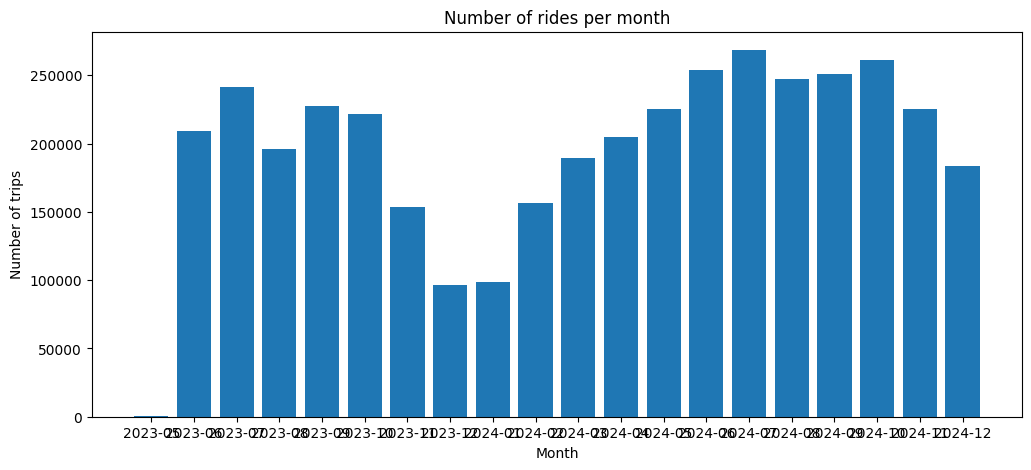

In [42]:
rides_per_month = (
    train_trips
    .set_index("starttime")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12,5))
plt.bar(rides_per_month.index.strftime("%Y-%m"), rides_per_month.values)
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Number of rides per month")
plt.show()

In [43]:
drop_cols = [
    "historical_idle_count_h3",
    "historical_avg_idle_h3",
    "trips_last_24h_h3",
    "trips_last_7d_h3",
    "time_since_last_trip_h3_min",
    "relative_demand_24h_h3",
    "relative_demand_24h_local",
    "local_trips_24h"
]

train_idling = train_idling.dropna(subset=drop_cols)
test_idling = test_idling.dropna(subset=drop_cols)

# Remove helper column
train_idling = train_idling.drop(columns="last_trip_time")
test_idling = test_idling.drop(columns="last_trip_time")

## Final check

In [44]:
train_idling.head(20)

,id,lat,lon,starttime,endtime,idle_duration_min,needs_relocation,h3_cell,neighbor_h3,hour,...,trips_last_7d_neighbor_h3,relative_demand_24h_h3,local_trips_24h,relative_demand_24h_local,temperature_2m,precipitation,weather_code,wind_speed_10m,is_raining,is_bad_weather
82,voiescooterhlud,48.136851,11.577553,2023-05-31 22:18:43,2023-06-01 08:03:55,585.200000,1,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,1,1.000000,2.0,2.000000,12.3,0.0,0,9.3,0,0
124,voiescootercdap,48.136876,11.577601,2023-05-31 22:27:42,2023-06-01 06:30:54,483.200000,1,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,1,0.333333,2.0,0.666667,12.3,0.0,0,9.3,0,0
126,voiescooternknu,48.136823,11.577560,2023-05-31 22:27:42,2023-06-01 00:48:42,141.000000,0,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,1,0.333333,2.0,0.666667,12.3,0.0,0,9.3,0,0
194,voiescooterkk4l,48.158150,11.552766,2023-05-31 22:45:38,2023-05-31 22:45:38,0.000000,0,891f8d44e67ffff,"[891f8d44e77ffff, 891f8d44e63ffff, 891f8d44e6f...",22,...,2,0.000000,3.0,3.000000,12.3,0.0,0,9.3,0,0
209,voiescooterl4fz,48.187536,11.562953,2023-05-31 22:48:41,2023-06-01 09:09:53,621.200000,1,891f8d44c17ffff,"[891f8d44c8fffff, 891f8d44c13ffff, 891f8d44c03...",22,...,1,1.000000,2.0,1.000000,12.3,0.0,0,9.3,0,0
218,voiescooters37r,48.132919,11.499701,2023-05-31 22:51:26,2023-06-01 12:21:42,810.266667,1,891f8d45c63ffff,"[891f8d45c73ffff, 891f8d45c7bffff, 891f8d45c6b...",22,...,2,1.000000,3.0,0.750000,12.3,0.0,0,9.3,0,0
224,voiescooter83q7,48.131977,11.566670,2023-05-31 22:51:39,2023-05-31 23:48:40,57.016667,0,891f8d7a4dbffff,"[891f8d459a7ffff, 891f8d459afffff, 891f8d45937...",22,...,0,1.000000,1.0,1.000000,12.3,0.0,0,9.3,0,0
225,voiescooter2rbs,48.187091,11.562084,2023-05-31 22:51:40,2023-05-31 23:27:42,36.033333,0,891f8d44c17ffff,"[891f8d44c8fffff, 891f8d44c13ffff, 891f8d44c03...",22,...,1,0.500000,2.0,0.666667,12.3,0.0,0,9.3,0,0
229,voiescooter5cvd,48.184873,11.584484,2023-05-31 22:51:46,2023-06-01 08:30:57,579.183333,1,891f8d44dcfffff,"[891f8d44dc3ffff, 891f8d44dcbffff, 891f8d44d53...",22,...,3,0.333333,4.0,0.666667,12.3,0.0,0,9.3,0,0
236,voiescooterjl35,48.117995,11.515642,2023-05-31 22:54:32,2023-06-01 13:48:50,894.300000,1,891f8d4587bffff,"[891f8d45847ffff, 891f8d4584fffff, 891f8d45ab7...",22,...,1,1.000000,2.0,2.000000,12.3,0.0,0,9.3,0,0


## Encoding
The last step before training the model is encoding features.
Most o fmy features that need to be encoded are time fetures. I woouldnt want to just leave them as integers becasye this suggests that monday (1) is 7 times smaller that Sunday (7) and that they are the furthers away from each other. Even tho in reality monday is just after sunday.
Thats why I will use a new to me approach of sine/cosine encoding.


In [45]:
# cyclic

for df in [train_idling, test_idling]:

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)




In [46]:
train_idling.head()

,id,lat,lon,starttime,endtime,idle_duration_min,needs_relocation,h3_cell,neighbor_h3,hour,...,weather_code,wind_speed_10m,is_raining,is_bad_weather,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
82,voiescooterhlud,48.136851,11.577553,2023-05-31 22:18:43,2023-06-01 08:03:55,585.2,1,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
124,voiescootercdap,48.136876,11.577601,2023-05-31 22:27:42,2023-06-01 06:30:54,483.2,1,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
126,voiescooternknu,48.136823,11.577560,2023-05-31 22:27:42,2023-06-01 00:48:42,141.0,0,891f8d7a483ffff,"[891f8d7a493ffff, 891f8d7a49bffff, 891f8d7a48b...",22,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
194,voiescooterkk4l,48.158150,11.552766,2023-05-31 22:45:38,2023-05-31 22:45:38,0.0,0,891f8d44e67ffff,"[891f8d44e77ffff, 891f8d44e63ffff, 891f8d44e6f...",22,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
209,voiescooterl4fz,48.187536,11.562953,2023-05-31 22:48:41,2023-06-01 09:09:53,621.2,1,891f8d44c17ffff,"[891f8d44c8fffff, 891f8d44c13ffff, 891f8d44c03...",22,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025


## I will create the final dataframe for training the model and separate the target value for test, and delete the features not useful anymore

In [47]:
y_train = train_idling["needs_relocation"]
y_test = test_idling["needs_relocation"]

X_train = train_idling.drop(
    columns=[
        "idle_duration_min",
        "id",
        "starttime",
        "endtime",
        "h3_cell",
        "neighbor_h3",
        "time_of_day",
        "hour",
        "weekday",
        "month",
        "local_trips_24h",
        "needs_relocation"
    ]
)

X_test = test_idling.drop(
    columns=[
        "idle_duration_min",
        "id",
        "starttime",
        "endtime",
        "h3_cell",
        "neighbor_h3",
        "time_of_day",
        "hour",
        "weekday",
        "month",
        "local_trips_24h",
        "needs_relocation"
    ]
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

print("\nTarget shape:")
print(y_train.shape)
print(y_test.shape)

Training features: (4124884, 27)
Test features: (1324591, 27)

Target shape:
(4124884,)
(1324591,)


In [48]:
X_train.head()

,lat,lon,is_weekend,historical_idle_count_h3,historical_avg_idle_h3,idle_scooters_same_h3,idle_scooters_neighbor_h3,idle_scooters_local_total,trips_last_24h_h3,trips_last_7d_h3,...,weather_code,wind_speed_10m,is_raining,is_bad_weather,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
82,48.136851,11.577553,0,1.0,0.000000,1,0,1,1.0,1.0,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
124,48.136876,11.577601,0,1.0,0.000000,3,0,3,1.0,1.0,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
126,48.136823,11.577560,0,1.0,0.000000,3,0,3,1.0,1.0,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
194,48.158150,11.552766,0,1.0,5.916667,0,1,1,1.0,1.0,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025
209,48.187536,11.562953,0,1.0,0.000000,1,1,2,1.0,1.0,...,0,9.3,0,0,-0.5,0.866025,0.974928,-0.222521,0.5,-0.866025


ML
type: supervised classification
task: classify if relocate
models: decision tree, random forest, xgboost


In [49]:
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("-------------------")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, dt_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree
-------------------
Accuracy:  0.7028
Precision: 0.6107
Recall:    0.4843
F1 Score:  0.5402
ROC-AUC:   0.7368

Confusion Matrix:
[[699662 147426]
 [246268 231235]]


In [50]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("-------------------")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest
-------------------
Accuracy:  0.7094
Precision: 0.6321
Recall:    0.4637
F1 Score:  0.5350
ROC-AUC:   0.7475

Confusion Matrix:
[[718215 128873]
 [256074 221429]]


In [51]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print("-------------------")
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost
-------------------
Accuracy:  0.7113
Precision: 0.6315
Recall:    0.4778
F1 Score:  0.5440
ROC-AUC:   0.7526

Confusion Matrix:
[[713964 133124]
 [249340 228163]]


In [52]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1": [
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, dt_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.711259,0.631528,0.477825,0.544029,0.752560
0,Decision Tree,0.702781,0.610665,0.484259,0.540165,0.736800
1,Random Forest,0.709384,0.632109,0.463723,0.534979,0.747509


## ML 
type: supervised, regression
task: predict idle time of scooters
target: idle_duration_min
models: decision tree, random forest, XGBoost
evaluation method: MAE, RMSE, R2, 

## Decison tree

In [53]:
# dt = DecisionTreeRegressor(
#     random_state=42
# )

# dt.fit(X_train, y_train)

# dt_pred = dt.predict(X_test)

In [54]:
# X_train.columns[np.isinf(X_train).any()]

In [55]:
# dt_mae = mean_absolute_error(y_test, dt_pred)
# dt_rmse = root_mean_squared_error(y_test, dt_pred)
# dt_r2 = r2_score(y_test, dt_pred)

# print(f"MAE:  {dt_mae:.2f}")
# print(f"RMSE: {dt_rmse:.2f}")
# print(f"R²:   {dt_r2:.4f}")

## Random forest

In [56]:
# rf = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# rf.fit(X_train, y_train)

# rf_pred = rf.predict(X_test)

In [57]:
# rf_mae = mean_absolute_error(y_test, rf_pred)

# rf_rmse = root_mean_squared_error(
#     y_test,
#     rf_pred
# )

# rf_r2 = r2_score(
#     y_test,
#     rf_pred
# )

# print(f"MAE:  {rf_mae:.2f}")
# print(f"RMSE: {rf_rmse:.2f}")
# print(f"R²:   {rf_r2:.4f}")

## XGBoost

In [58]:
# xgb = XGBRegressor(
#     n_estimators=100,
#     random_state=42,
#     learning_rate=0.1,
#     max_depth=6,
#     objective="reg:squarederror"
# )

# xgb.fit(X_train, y_train)

# xgb_pred = xgb.predict(X_test)

In [59]:
# xgb_mae = mean_absolute_error(y_test, xgb_pred)

# xgb_rmse = root_mean_squared_error(
#     y_test,
#     xgb_pred
# )

# xgb_r2 = r2_score(
#     y_test,
#     xgb_pred
# )

# print(f"MAE:  {xgb_mae:.2f}")
# print(f"RMSE: {xgb_rmse:.2f}")
# print(f"R²:   {xgb_r2:.4f}")

### Summary

In [60]:
# results = pd.DataFrame({
#     "Model": [
#         "Decision Tree",
#         "Random Forest",
#         "XGBoost"
#     ],
#     "MAE": [
#         dt_mae,
#         rf_mae,
#         xgb_mae
#     ],
#     "RMSE": [
#         dt_rmse,
#         rf_rmse,
#         xgb_rmse
#     ],
#     "R²": [
#         dt_r2,
#         rf_r2,
#         xgb_r2
#     ]
# })

# results.sort_values(
#     by="RMSE"
# )